In [18]:
import os
import shutil
import random
import tqdm
import torch
import torchaudio
import torchaudio.functional as ff
import torchaudio.transforms as tt
import matplotlib.pyplot as plt

In [19]:
ROOT_SRC = '/home/ovistetom/Documents/Databases_Local/LIBRISPEECH/original/speakers'
ROOT_DST = '/home/ovistetom/Documents/Databases_Local/LIBRISPEECH/preprocessed'
SAMPLE_RATE = 16000
os.makedirs(ROOT_DST, exist_ok=True)

In [20]:
list_speakers = os.listdir(ROOT_SRC)
num_speakers = len(list_speakers)
random.shuffle(list_speakers)
print(list_speakers[:10])

['1535', '1498', '8722', '7140', '5561', '7190', '2319', '159', '5635', '1898']


In [21]:
tst_size = int(0.1*num_speakers)
val_size = int(0.1*num_speakers)
trn_size = num_speakers - val_size - tst_size
list_trn = list_speakers[:trn_size]
list_val = list_speakers[trn_size:trn_size+val_size]
list_tst = list_speakers[trn_size+val_size:]
print(len(list_trn), len(list_val), len(list_tst))

1002 125 125


In [22]:
RESAMPLER = tt.Resample(orig_freq=48000, new_freq=SAMPLE_RATE)
FADER = tt.Fade(fade_in_len=64, fade_out_len=64)

In [23]:
for name_subset, list_subset in zip(['trn', 'val', 'tst'], [list_trn, list_val, list_tst]):

    path_subset_dst = os.path.join(ROOT_DST, name_subset)
    os.makedirs(path_subset_dst, exist_ok=True)

    for name_speaker in tqdm.tqdm(list_subset):

        path_speaker_src = os.path.join(ROOT_SRC, name_speaker)
        if not os.path.isdir(path_speaker_src):
            continue

        for name_book in os.listdir(path_speaker_src):
            path_book_src = os.path.join(path_speaker_src, name_book)
            if not os.path.isdir(path_book_src):
                continue

            for name_sample in os.listdir(path_book_src):

                if not name_sample.endswith('.flac'):
                    continue

                path_sample_src = os.path.join(path_book_src, name_sample)
                path_sample_dst = os.path.join(path_subset_dst, name_sample)
                waveform, sr = torchaudio.load(uri=path_sample_src, normalize=True, channels_first=True)

                if waveform.size(0) > 1:
                    waveform = waveform[0].unsqueeze(0)

                if waveform.mean() > 0.1:
                    waveform = waveform - waveform.mean()

                if sr != SAMPLE_RATE:
                    assert sr == 48000, f"Sample rate {sr} not supported."
                    waveform = RESAMPLER(waveform)
                
                waveform = FADER(waveform)
                waveform = waveform / waveform.abs().max()

                torchaudio.save(uri=path_sample_dst, src=waveform, sample_rate=SAMPLE_RATE, channels_first=True, format='flac')


100%|██████████| 125/125 [04:33<00:00,  2.19s/it]


___

## Analyse Dataset

In [24]:
ROOT_DB = os.path.join(ROOT_DST, 'trn')

list_waveform_length = []
list_waveform_power = []
for sample_name in os.listdir(ROOT_DB):
    sample_path = os.path.join(ROOT_DB, sample_name)
    waveform, sr = torchaudio.load(uri=sample_path, normalize=True, channels_first=True)
    list_waveform_length.append(waveform.size(1) / sr)
    list_waveform_power.append((waveform.pow(2).sum() / waveform.size(1)).log().item())

print(f"Num. samples: {len(list_waveform_length)}")

Num. samples: 110262


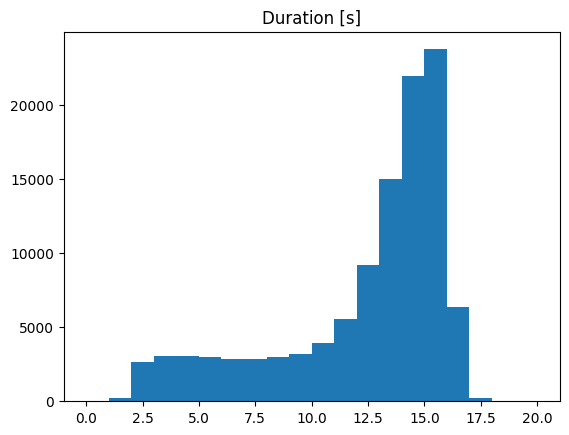

In [25]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_length, bins=20, range=(0, 20))
axs.set_title('Duration [s]')
plt.show()

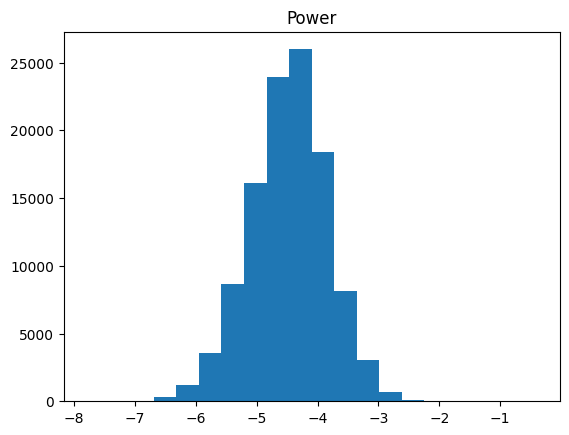

In [26]:
fig, axs = plt.subplots(1,1)
axs.hist(list_waveform_power, bins=20)
axs.set_title('Power')
plt.show()

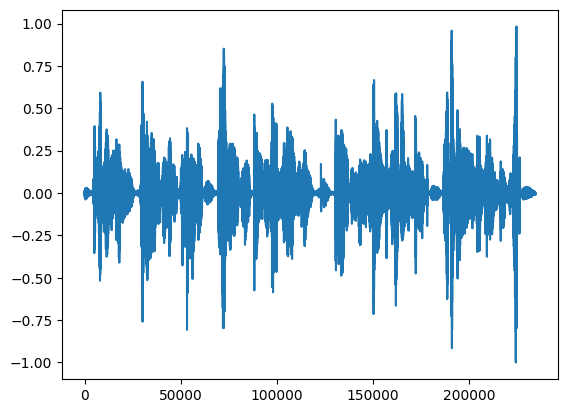

In [27]:
plt.plot(waveform.mT.numpy())